# Caso Práctico: Distribución Normal

## Imports

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.gridspec as gridspec
from collections import Counter
from sklearn import metrics
import numpy as np
from matplotlib.colors import LogNorm
from sklearn.metrics import f1_score

## 1. Lectura del conjunto de datos

In [2]:
df = pd.read_csv("creditcard.csv")

## 2. Visualización del conjunto de datos

In [3]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [4]:
print("Número de variables:", len(df.columns))
print("Longitud del conjunto de datos:", len(df))

Número de variables: 31
Longitud del conjunto de datos: 284807


In [5]:
# 492 transacciones fraudulentas, 284315 transacciones legitimas
# El conjunto de datos se encuntra desequilabrado
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [6]:
# Visualizamos los tipos de cada uno de los atributos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
# Comprobamos si alguna columna tiene valores nulos
df.isna().any()

,0
Time,False
V1,False
V2,False
V3,False
V4,False
V5,False
V6,False
V7,False
V8,False
V9,False


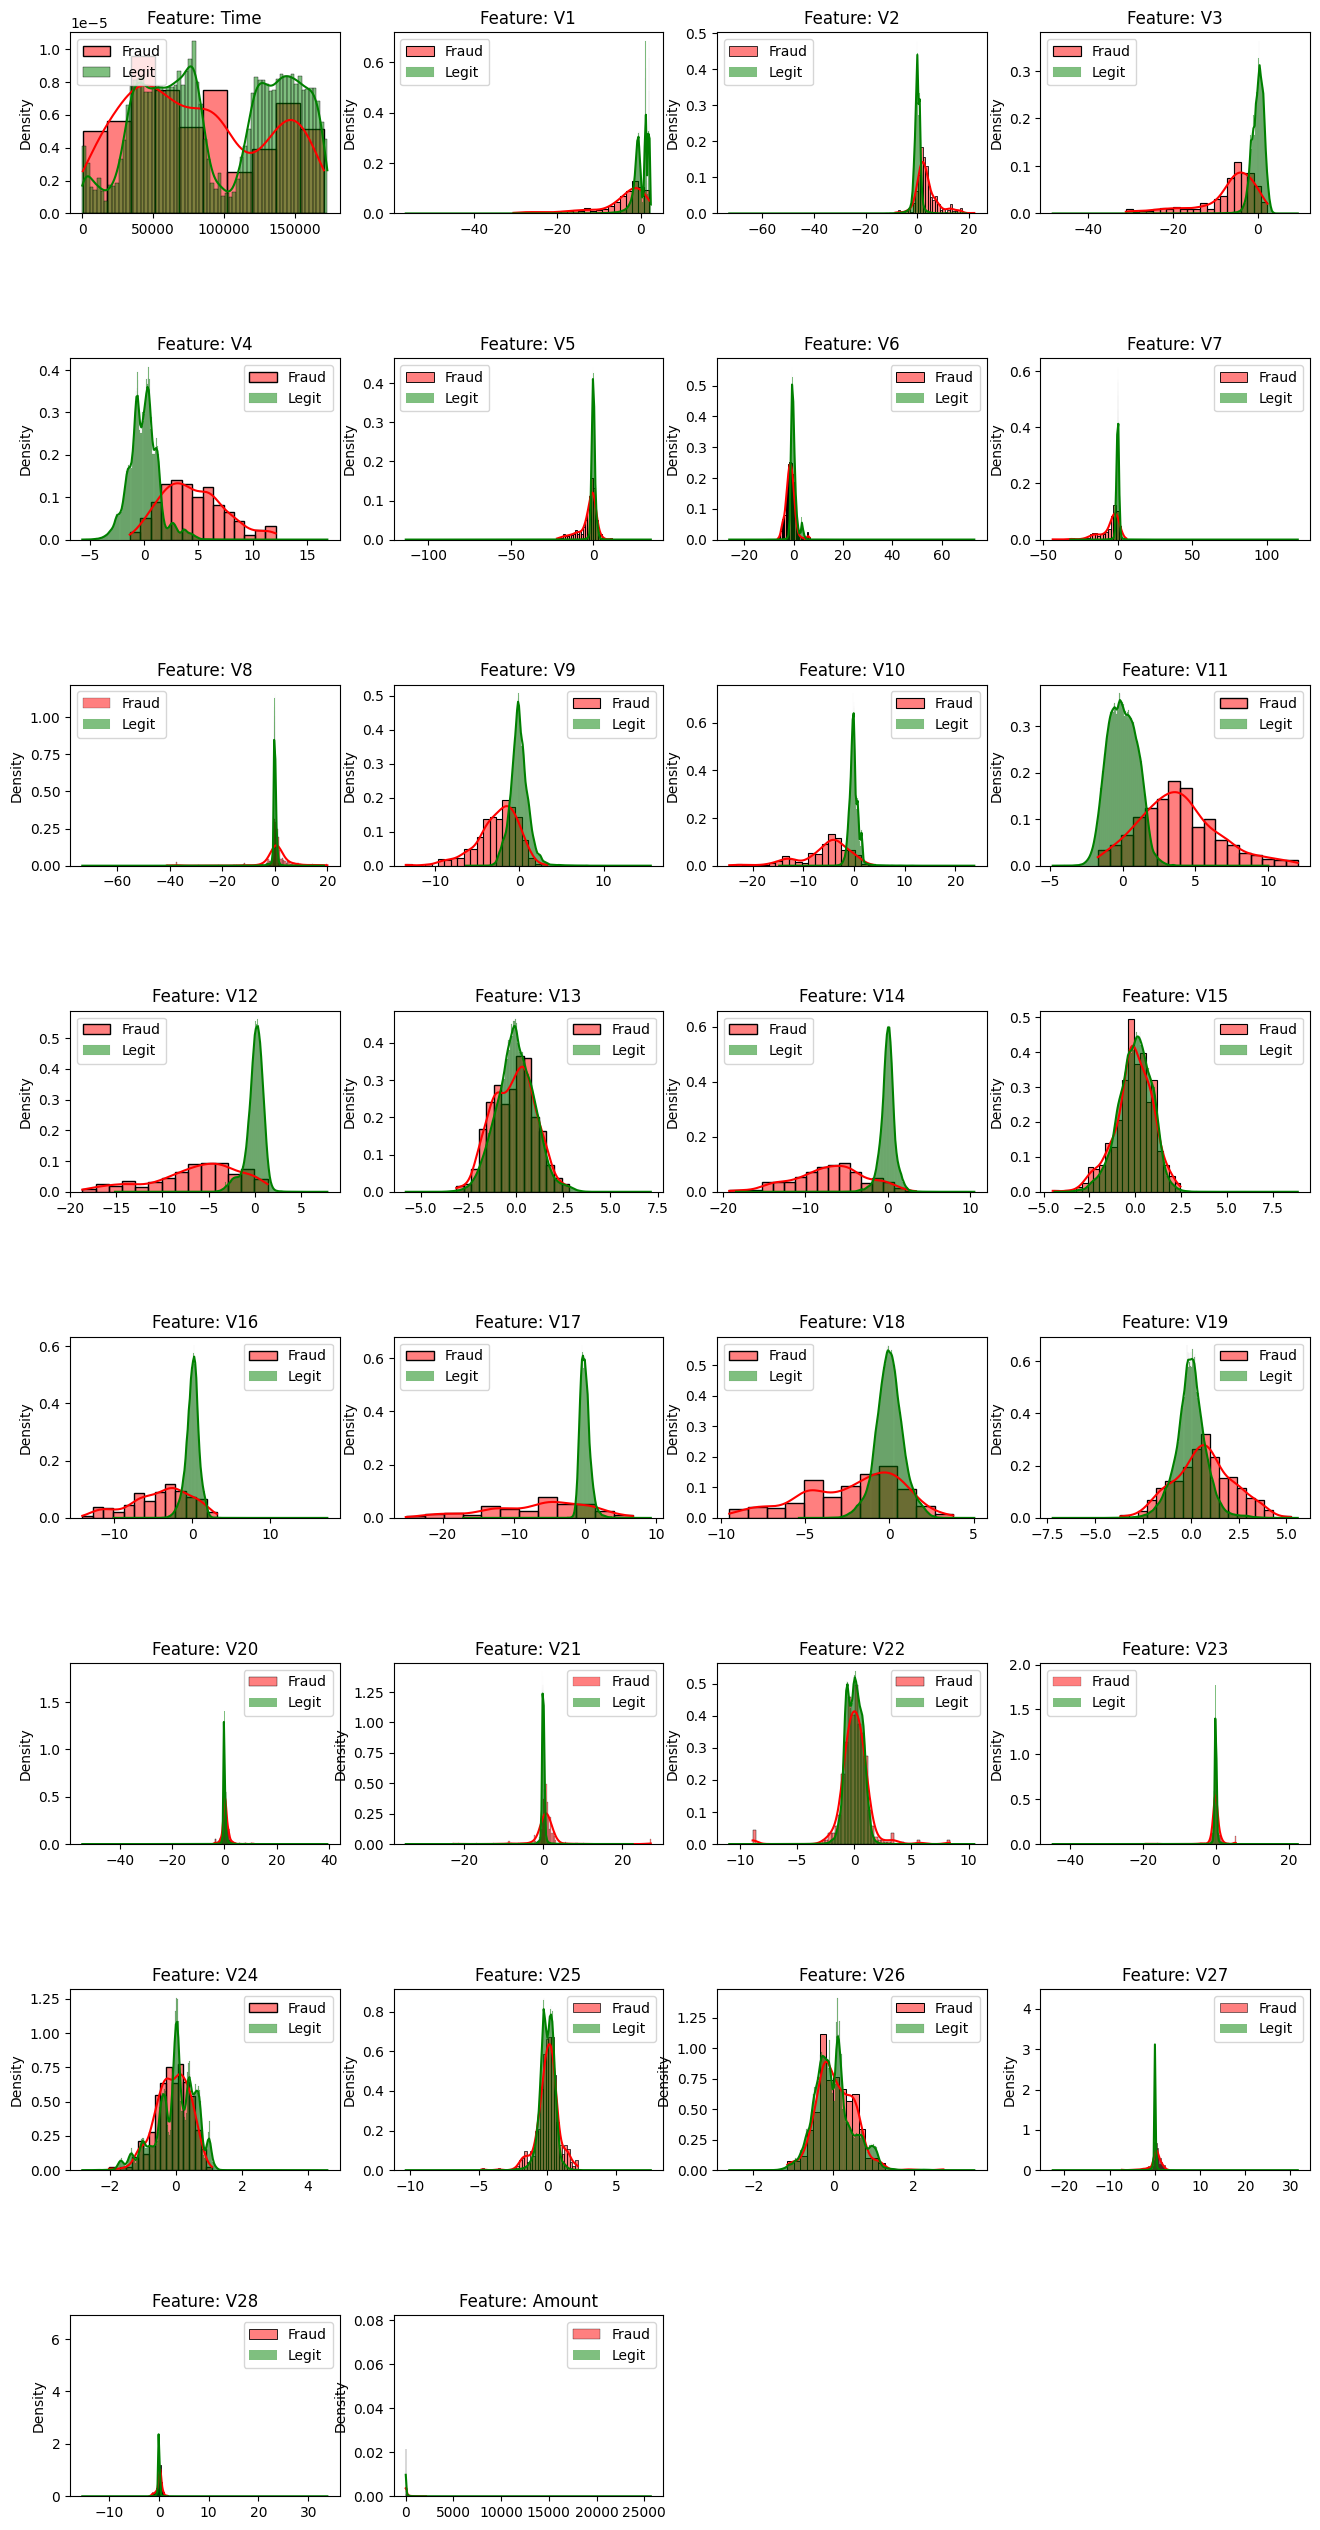

In [8]:
# Representamos gráficamente las variables
features = df.drop("Class", axis=1)

plt.figure(figsize=(16, 32))
gs = gridspec.GridSpec(8, 4)
gs.update(hspace=0.8)

for i, f in enumerate(features):
    ax = plt.subplot(gs[i])
    # Usando histplot para los casos donde Class == 1
    sns.histplot(data=df[df["Class"] == 1], x=f, kde=True, color="red", stat="density", label="Fraud", alpha=0.5)
    # Usando histplot para los casos donde Class == 0
    sns.histplot(data=df[df["Class"] == 0], x=f, kde=True, color="green", stat="density", label="Legit", alpha=0.5)
    ax.set_xlabel('')
    ax.set_title(f"Feature: {f}")
    ax.legend()

plt.show()

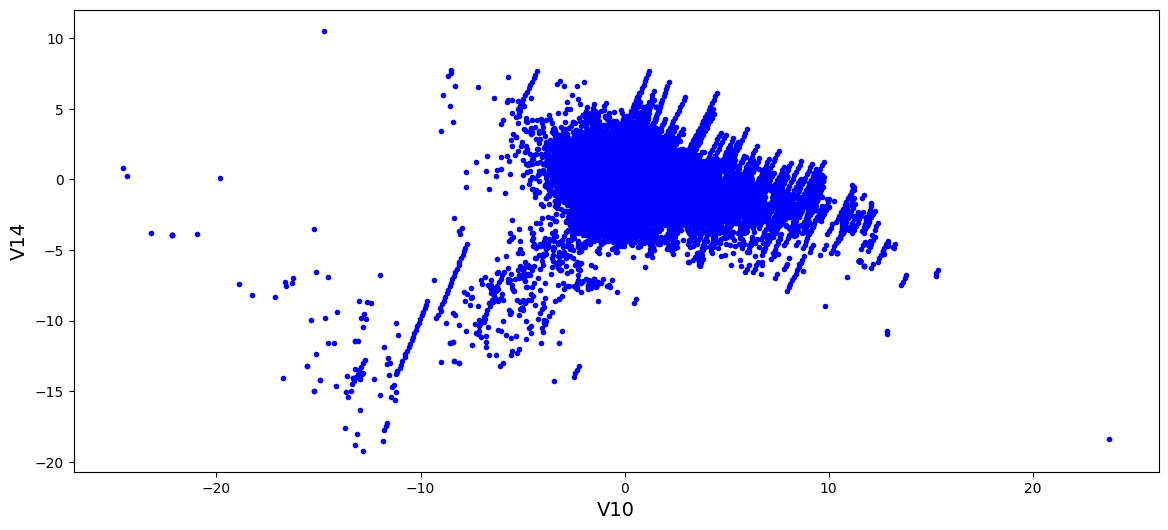

In [9]:
# Representación gráfica de dos variables
plt.figure(figsize=(14, 6))
plt.scatter(df["V10"][df['Class'] == 0], df["V14"][df['Class'] == 0], c="b", marker=".")
plt.scatter(df["V10"][df['Class'] == 1], df["V14"][df['Class'] == 1], c="b", marker=".")
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

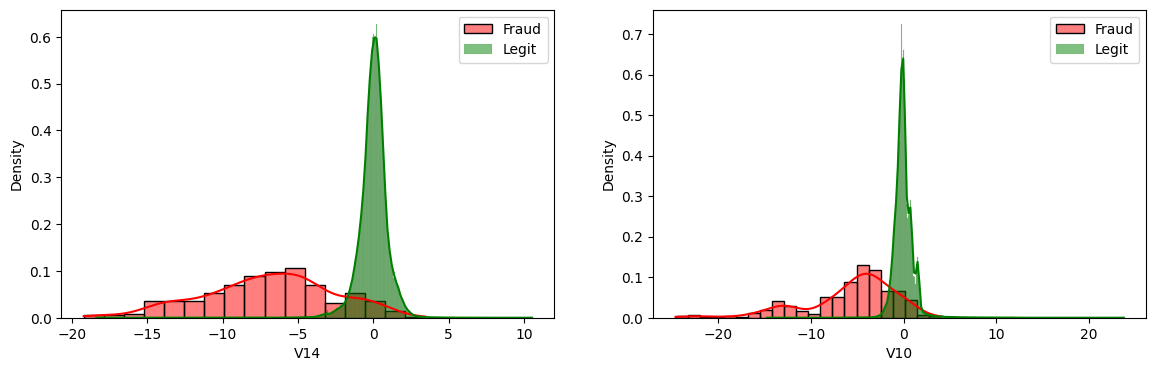

In [10]:
plt.figure(figsize=(14,4))
gs = gridspec.GridSpec(1, 2)

# Representación de la variable 1
ax = plt.subplot(gs[0])
sns.histplot(data=df[df['Class'] == 1], x="V14", kde=True, color="red", stat="density", label="Fraud", alpha=0.5)
sns.histplot(data=df[df['Class'] == 0], x="V14", kde=True, color="green", stat="density", label="Legit", alpha=0.5)
ax.legend()  # Para mostrar la leyenda

# Representación de la variable 2
ax = plt.subplot(gs[1])
sns.histplot(data=df[df['Class'] == 1], x="V10", kde=True, color="red", stat="density", label="Fraud", alpha=0.5)
sns.histplot(data=df[df['Class'] == 0], x="V10", kde=True, color="green", stat="density", label="Legit", alpha=0.5)
ax.legend()  # Para mostrar la leyenda

plt.show()

## 3. Preparación del conjunto de datos

Para este tipo de algoritmos es importante que todos los datos se encuentren en un rango similar, por lo tanto, podemos aplicar una función de escalado o normalización. Otra opción, es eliminar las variables que no se encuentran en un rango similar siempre y cuando no sean muy influyentes para la predicción.

In [11]:
df_prep = df.drop(["Time", "Amount"], axis=1)

## 4. Distribución Gaussiana con un conjunto de datos de dos dimensiones

Antes de comenzar con la detección de anomalías mediante distribución Gaussiana para todos los atributos del conjunto de datos, se realiza una prueba para dos atributos con el objetivo de comprender como construye el límite de decisión.

In [12]:
X = df_prep.drop("Class", axis=1)
y = df_prep["Class"]

In [13]:
X_reduced = X[["V10", "V14"]]

**Entrenamiento del algoritmo con un conjunto de datos reducido**

In [14]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=2, random_state=42)
gm.fit(X_reduced)

GaussianMixture(n_components=2, random_state=42)

- n_components -> número de campanas
- fit -> Hasta que gaussino va a poner

**Representación del límite de decisión**

In [15]:
def plot_gaussian_mixture(clusterer, X, y, resolution=1000):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clusterer.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.plot(X[:, 0][y==0], X[:, 1][y==0], 'k.', markersize=2)
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], 'r.', markersize=2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


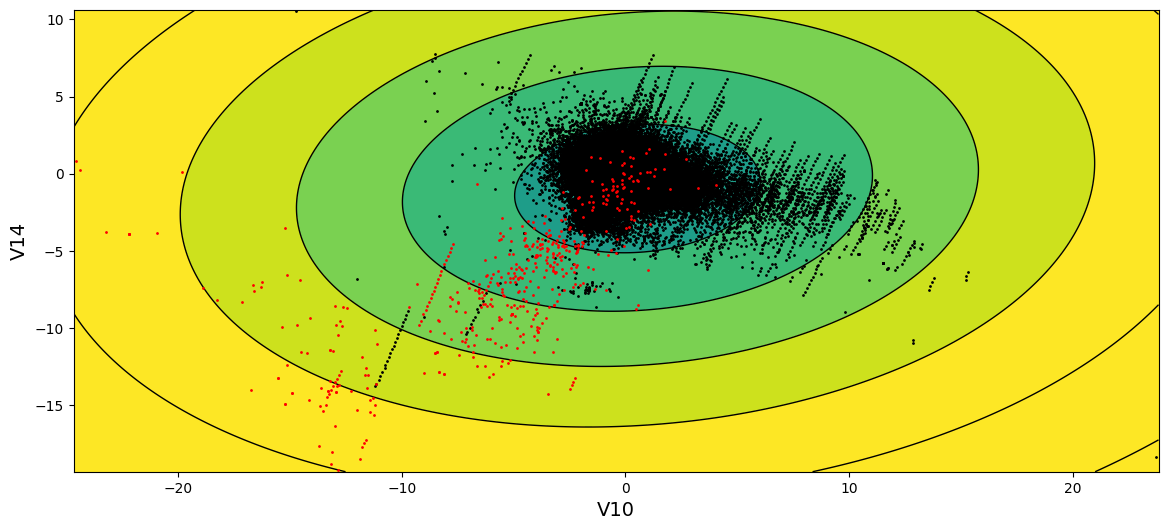

In [17]:
plt.figure(figsize=(14, 6))
plot_gaussian_mixture(gm, X_reduced.values, y)
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

#Colores -> curvas de nivel

**Representación de las anomalías identificadas**

Para la identificación de las anomalías, se debe seleccionar un límite a partir del cual, todos los ejemplos que se encuentren en regiones con una densidad menor a la indicada en el límite, se consideran anomalías.

In [19]:
# Selección del Límite
densities = gm.score_samples(X_reduced)
density_threshold = np.percentile(densities, 0.05)  #0.5 -> deja el 5% de probabilidad afuera
print("Límite seleccionado:", density_threshold)

Límite seleccionado: -18.168122111359597


In [20]:
# Identificación de anomalías
anomalies = X_reduced.values[densities < density_threshold]

En la gráfica que se muestra a continuación, aparecen resltadas en verde las anomalías identificadas para el conjunto de datos de entrenamiento y el valor del threshold seleccionado anteriormente.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


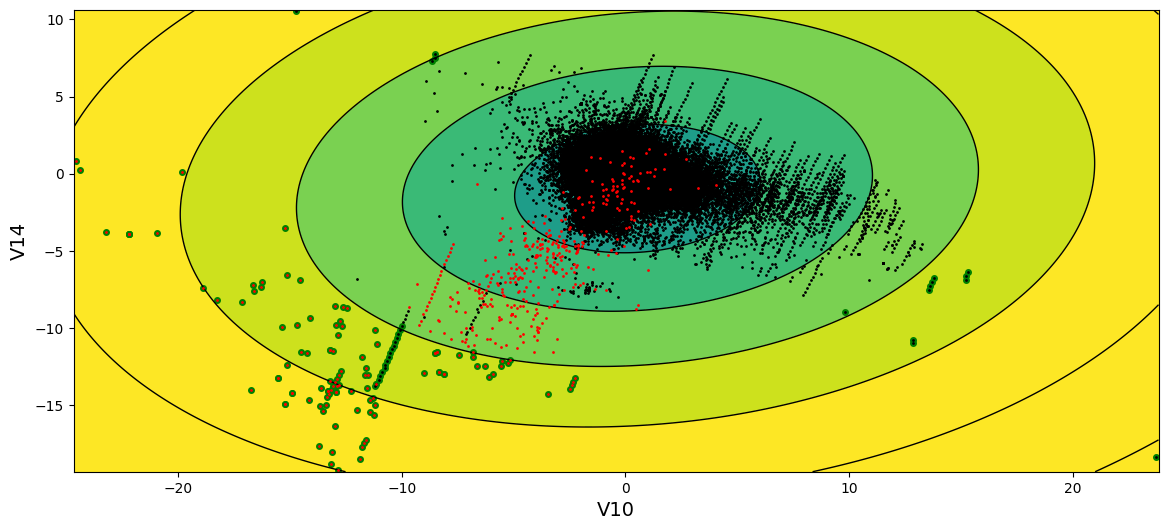

In [21]:
# Representación gráfica de las anomalías
plt.figure(figsize=(14, 6))
plt.plot(anomalies[:, 0], anomalies[:, 1], 'go', markersize=4)
plot_gaussian_mixture(gm, X_reduced.values, y)
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

Coloreó en verde los muy alejados -> anómalos

**Predicción con el conjunto de datos reducido**

In [22]:
# Listado de los puntos anómalos
y_preds = (densities < density_threshold)
X_reduced[y_preds == True]

,V10,V14
6717,-7.454841,-11.736729
6719,-6.810813,-11.543498
8296,-12.840934,-19.214325
8335,-11.420451,-14.690729
8615,-13.193415,-18.822087
...,...,...
251477,-5.172812,-12.043806
252124,-6.646154,-12.456706
252774,-5.533443,-12.156587
262826,-6.120715,-13.202505


## 5. Distribución Gaussiana con un conjunto de datos multidimensional

In [23]:
# Entrenamiento del modelo
gm = GaussianMixture(n_components=2, random_state=42)
gm.fit(X)

GaussianMixture(n_components=2, random_state=42)

In [24]:
# Selección del Límite
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 0.05)
print("Límite seleccionado:", density_threshold)

Límite seleccionado: -546.2416773342798


In [25]:
# Listado de los puntos anómalos
y_preds = (densities < density_threshold)
X[y_preds == True]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
1632,-11.140706,-9.612726,-12.389545,6.013346,-32.092129,21.393069,34.303177,-7.520784,-1.925732,-2.636622,...,0.752276,-11.748689,-4.709977,1.366110,-2.925888,0.843551,0.746267,0.801387,3.852046,4.157934
6812,-23.066842,-25.640527,-3.080313,4.866932,6.901397,-4.074335,2.027345,-2.688652,3.402966,2.881873,...,2.693421,-13.276034,-5.378106,3.312971,13.876221,-0.572177,5.525093,0.906980,3.358822,3.553906
8610,-27.670569,-34.607649,2.243079,10.463020,34.099309,-23.496714,-26.548144,-0.779134,7.496577,6.605512,...,4.555359,-12.834042,-4.651023,-1.627883,-11.669994,2.192626,-2.483069,1.788189,8.254376,-3.509250
10690,-12.224021,3.854150,-12.466766,9.648311,-2.726961,-4.445610,-21.922811,0.320792,-4.433162,-11.201400,...,1.606870,-2.147181,-1.159830,-1.504119,-19.254328,0.544867,-4.781606,-0.007772,3.052358,-0.775036
15168,-3.156608,-2.895171,3.300964,1.550562,16.160824,-8.710536,-17.936966,0.492347,1.851809,3.333234,...,-1.173909,-1.444388,0.831647,-4.120410,-26.751119,0.002922,-7.495741,-0.376964,1.811647,1.056891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262843,-34.092032,-24.237418,-15.758012,12.672760,-14.913249,7.939152,11.118494,-1.985873,5.693151,6.601719,...,2.772667,-14.562079,-6.406856,-1.384773,-13.615143,1.542827,-0.332634,-0.058112,-6.782493,14.974180
265657,-24.717179,-29.700604,-2.017586,7.015138,15.700555,-10.819584,-3.586669,-1.336900,3.279434,1.437047,...,3.477968,-11.753658,-4.410023,3.820005,22.083545,-0.098109,6.070850,1.461475,6.578849,-4.398798
274771,-35.548539,-31.850484,-48.325589,15.304184,-113.743307,73.301626,120.589494,-27.347360,-3.872425,-12.005487,...,5.501747,-54.497720,-21.620120,5.712303,-1.581098,4.584549,4.554683,3.415636,31.612198,-15.430084
279610,-25.672101,-30.913347,-2.943712,5.330375,11.886791,-8.036176,-1.273707,-1.444300,2.047691,1.271063,...,2.841875,-11.312828,-4.777701,2.097348,20.803344,0.290511,5.826159,0.578662,6.987314,-3.666456
